<a href="https://colab.research.google.com/github/padilxd/analisis_visual/blob/main/dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Menggunakan dataset contoh (bisa diganti dengan path file Kaggle Anda)

df = pd.read_csv ('data_penjualan.csv')
print(df.head())


   Order_ID  CustomerID  Order_Date Product_Category  Quantity  \
0      1001        5039  2023-08-19            Books         4   
1      1002        5029  2023-08-29          Fashion         5   
2      1003        5015  2023-02-21          Fashion         4   
3      1004        5043  2023-04-06          Fashion         2   
4      1005        5008  2023-08-10       Home Decor         2   

   Price_Per_Unit  Ad_Budget  Total_Sales  
0       1184000.0   982000.0    4736000.0  
1       1733000.0  3513000.0    8665000.0  
2       1767000.0  2117000.0    7068000.0  
3        512000.0  4384000.0    1024000.0  
4       1820000.0  2625000.0    3640000.0  


# New Section

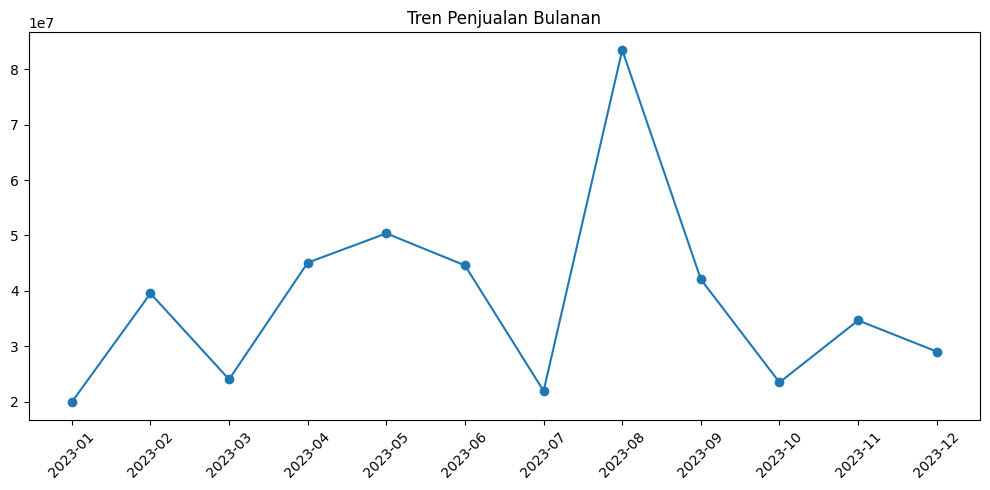

In [6]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

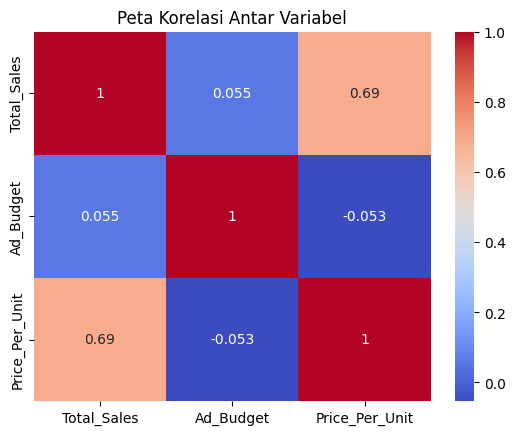

In [7]:
correlation = df[['Total_Sales', 'Ad_Budget', 'Price_Per_Unit']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()

# New Section

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

df = pd.read_csv('data_penjualan.csv')
df.head()

,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0


In [31]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          150 non-null    int64         
 1   CustomerID        150 non-null    int64         
 2   Order_Date        150 non-null    datetime64[ns]
 3   Product_Category  150 non-null    object        
 4   Quantity          150 non-null    int64         
 5   Price_Per_Unit    150 non-null    float64       
 6   Ad_Budget         150 non-null    float64       
 7   Total_Sales       143 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(1)
memory usage: 9.5+ KB


In [32]:
avg_price = df['Price_Per_Unit'].mean()

underperformer = df.groupby('Product_Category').agg({
    'Price_Per_Unit': 'mean',
    'Quantity': 'sum'
}).reset_index()

under_filtered = underperformer[
    underperformer['Price_Per_Unit'] > avg_price
].sort_values(by='Quantity')

under_filtered

,Product_Category,Price_Per_Unit,Quantity
4,Home Decor,1.029583e+06,71
2,Fashion,1.032000e+06,95
1,Electronics,1.109871e+06,100
0,Books,1.047941e+06,110


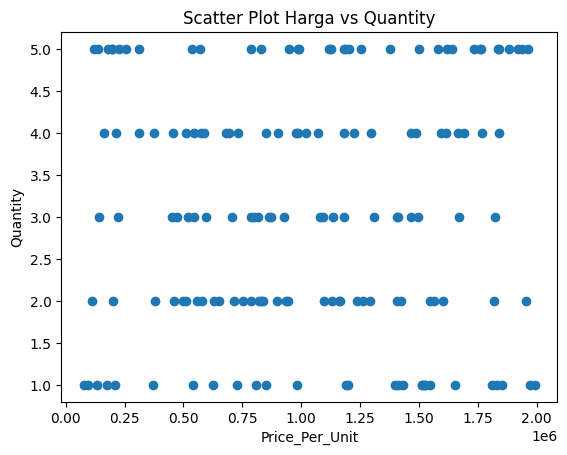

In [33]:
plt.scatter(df['Price_Per_Unit'], df['Quantity'])
plt.xlabel('Price_Per_Unit')
plt.ylabel('Quantity')
plt.title('Scatter Plot Harga vs Quantity')
plt.show()

In [34]:
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
5001,213,4,8562000.0
5002,77,4,6931000.0
5003,118,3,9433000.0
5004,196,3,15368000.0
5005,23,2,9105000.0


In [35]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group
CustomerID,,,,,,,
5001,213,4,8562000.0,1,4,3,143
5002,77,4,6931000.0,3,4,3,343
5003,118,3,9433000.0,3,2,3,323
5004,196,3,15368000.0,2,3,4,234
5005,23,2,9105000.0,5,2,3,523


In [36]:
def segment(row):
    if row['RFM_Group'] == '555':
        return 'Champion'
    elif int(row['R_Score']) <= 2:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group,Segment
CustomerID,,,,,,,,
5001,213,4,8562000.0,1,4,3,143,At Risk
5002,77,4,6931000.0,3,4,3,343,Regular
5003,118,3,9433000.0,3,2,3,323,Regular
5004,196,3,15368000.0,2,3,4,234,At Risk
5005,23,2,9105000.0,5,2,3,523,Regular


In [37]:
kategori = df.groupby('Product_Category').agg({
    'Total_Sales': 'sum',
    'Ad_Budget': 'sum'
})

kategori['Efficiency'] = kategori['Total_Sales'] / kategori['Ad_Budget']
kategori = kategori.sort_values(by='Efficiency')

kategori

,Total_Sales,Ad_Budget,Efficiency
Product_Category,,,
Gadget,70523000.0,76539000.0,0.921400
Home Decor,69340000.0,64808000.0,1.069930
Fashion,96550000.0,82317000.0,1.172905
Books,107569000.0,89914000.0,1.196354
Electronics,114095000.0,79264000.0,1.439430


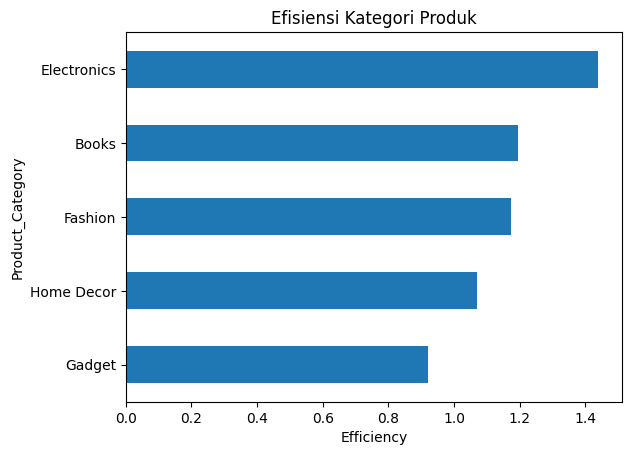

In [38]:
kategori['Efficiency'].plot(kind='barh')
plt.title('Efisiensi Kategori Produk')
plt.xlabel('Efficiency')
plt.show()

In [44]:
median_ads = df['Ad_Budget'].median()

high_ads = df[df['Ad_Budget'] > median_ads]
low_ads = df[df['Ad_Budget'] <= median_ads]

print("Rata-rata Sales (High Ads):", high_ads['Total_Sales'].mean())
print("Rata-rata Sales (Low Ads):", low_ads['Total_Sales'].mean())

Rata-rata Sales (High Ads): 3156275.362318841
Rata-rata Sales (Low Ads): 3247216.2162162163


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Create a cleaned DataFrame by dropping rows with NaN in 'Total_Sales'
df_cleaned = df.dropna(subset=['Total_Sales'])

X = df_cleaned[['Ad_Budget']]
y = df_cleaned['Total_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Koefisien Iklan:", model.coef_[0])
print("R2 Score:", model.score(X_test, y_test))

Koefisien Iklan: 0.1841982749623798
R2 Score: -0.1956467472142791
